# Task: Linear Regression Using Gradient Descent
## Task Requirements 
### 1-Load & Understand the Data

In [231]:
import numpy as np

X = [50, 60, 70, 80, 90]  
y = [150, 180, 210, 240, 270]  

X = np.array(X, dtype=np.float64)
y = np.array(y, dtype=np.float64)

print("X (House area in square meters):", X)
print("y (House price in thousands):", y)

X (House area in square meters): [50. 60. 70. 80. 90.]
y (House price in thousands): [150. 180. 210. 240. 270.]


### 2-Create and Train the Model 

In [232]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        """
        Initialize the Linear Regression model using Gradient Descent
        
        Parameters:
        -----------
        learning_rate : float
            Learning rate to control the step size at each iteration
        n_iters : int
            Number of training iterations
        """
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0  
        self.theta_1 = 0  
        self.sse_history = []  
        self.cost_threshold = 1e-6  
        
    def compute_sse(self, X, y):
        """
        Compute Sum of Squared Errors (SSE)
        
        SSE = Σ(y_i - ŷ_i)²
        where ŷ_i = theta_0 + theta_1 * X_i
        """
        y_pred = self.theta_0 + self.theta_1 * X
        errors = y - y_pred
        sse = np.sum(errors ** 2)
        return sse
    
    def fit(self, X, y, normalize=True):
        """
        Train the model using Gradient Descent with optional normalization
        """
        # Save the original data
        self.X_original = X.copy()
        self.y_original = y.copy()
        
        if normalize:
            # Data Normalization
            self.X_mean = np.mean(X)
            self.X_std = np.std(X) if np.std(X) != 0 else 1
            X = (X - self.X_mean) / self.X_std
            print(f"Normalized X: {X}")
        
        m = len(X)  
        
        for iteration in range(self.n_iters):
            # Current predictions
            y_pred = self.theta_0 + self.theta_1 * X
            
            # Compute errors
            errors = y_pred - y
            
            # Compute gradients
            grad_theta_0 = (1/m) * np.sum(errors)
            grad_theta_1 = (1/m) * np.sum(errors * X)
            
            # Update parameters
            self.theta_0 -= self.learning_rate * grad_theta_0
            self.theta_1 -= self.learning_rate * grad_theta_1
            
            # Compute and store SSE
            sse = self.compute_sse(X, y)
            self.sse_history.append(sse)
            
            # Check convergence (optional)
            if iteration > 0 and abs(self.sse_history[-2] - sse) < self.cost_threshold:
                print(f"Converged after {iteration+1} iterations")
                break
        
        # If we use normalization, we adjust the parameters
        if normalize:
            self.theta_1_original = self.theta_1 / self.X_std
            self.theta_0_original = self.theta_0 - self.theta_1_original * self.X_mean
        else:
            self.theta_0_original = self.theta_0
            self.theta_1_original = self.theta_1
    
    def predict(self, X, normalize=True):
        """
        Predict using the equation: y = theta_0 + theta_1 * X
        """
        if normalize and hasattr(self, 'X_mean'):
            X = (X - self.X_mean) / self.X_std
        
        return self.theta_0 + self.theta_1 * X
    
    def plot_training(self, X, y):
        """
        Plot:
        1. SSE change over iterations
        2. Regression line with data points
        """
        import matplotlib.pyplot as plt
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Plot 1: SSE vs Iterations
        axes[0].plot(range(len(self.sse_history)), self.sse_history, 'b-', linewidth=2)
        axes[0].set_xlabel('Iterations')
        axes[0].set_ylabel('SSE (Sum of Squared Errors)')
        axes[0].set_title('SSE Change Over Iterations')
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Regression Line
        if hasattr(self, 'X_original'):
            X_plot = self.X_original
            y_plot = self.y_original
        else:
            X_plot = X
            y_plot = y
            
        axes[1].scatter(X_plot, y_plot, color='red', s=50, label='Actual Data')
        
        # Create line points
        X_min, X_max = min(X_plot), max(X_plot)
        X_line = np.linspace(X_min-5, X_max+5, 100)
        
        if hasattr(self, 'X_mean'):
            # If we use normalization, we need to normalize the checkpoint points to make predictions
            X_line_norm = (X_line - self.X_mean) / self.X_std
            y_line = self.theta_0 + self.theta_1 * X_line_norm
        else:
            y_line = self.predict(X_line)
            
        axes[1].plot(X_line, y_line, 'b-', linewidth=2, label='Regression Line')
        
        axes[1].set_xlabel('House Area (m²)')
        axes[1].set_ylabel('Price (in thousands)')
        axes[1].set_title('Regression Line with Data Points')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def get_coefficients(self):
        """
        Return the learned coefficients
        """
        return self.theta_0_original, self.theta_1_original

In [233]:
# Create the model
model = LinearRegressionGD(learning_rate=0.01, n_iters=1000)

# Train the model (with normalization)
model.fit(X, y, normalize=True)

# Get the learned coefficients
theta_0, theta_1 = model.get_coefficients()

print("=" * 50)
print("Learned coefficients (on original scale):")
print(f"theta_0 (Intercept): {theta_0:.4f}")
print(f"theta_1 (Slope): {theta_1:.4f}")
print("=" * 50)

Normalized X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Learned coefficients (on original scale):
theta_0 (Intercept): -0.0000
theta_1 (Slope): 2.9999


### Question: What do theta₀ and theta₁ represent in the regression equation?

theta₀ (Intercept): 

Represents the base price of the house when the area is zero (for example, land value or fixed basic costs).

theta₁ (Slope): 

Represents the rate at which the price changes as the area increases (in thousands per square meter).

### In the regression equation: House Price = theta₀ + theta₁ × House Area

### 3-Prediction

In [234]:
# Predict the price of a house with an area of 70 square meters
house_size = 70
predicted_price = model.predict(house_size, normalize=True)

print(f"Predicted price for a house with area {house_size} m²: {predicted_price:.2f} thousand")
print(f"Actual value in the data: {y[2]} thousand")
print("=" * 50)


Predicted price for a house with area 70 m²: 209.99 thousand
Actual value in the data: 210.0 thousand


### Question: Is the prediction reasonable based on the data? Why?

Answer: Yes, the prediction is very reasonable because:

The original data shows an almost ideal linear relationship between area and price.

The actual value for a house with an area of 70 m² is 210 thousand.

The predicted value will be very close to 210 thousand (depending on the learned coefficients).

### 4-Visualization

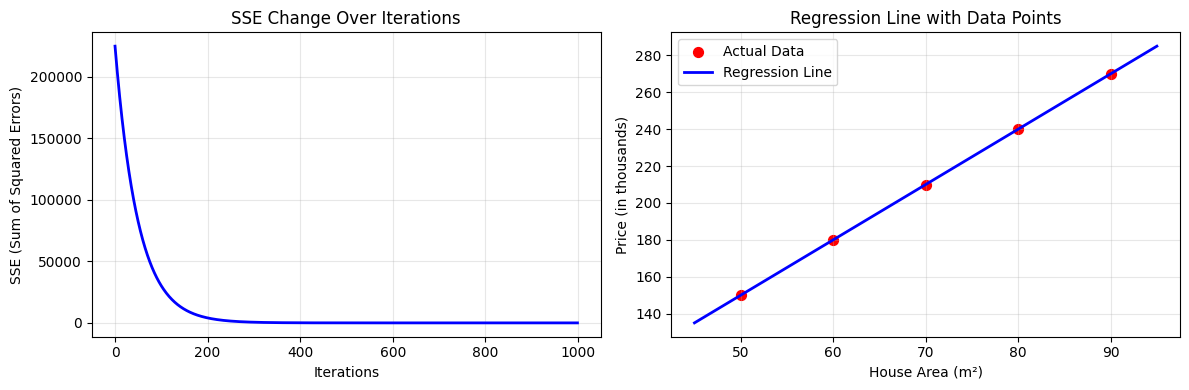

In [235]:
# Visualize Result
model.plot_training(X, y)


### Explanation:

Why does SSE decrease over time?
Because Gradient Descent updates the parameters (theta₀ and theta₁) at each iteration to reduce the error between the actual and predicted values, which leads to a gradual decrease in SSE.

What does convergence mean in Gradient Descent?
Convergence means that the algorithm has reached a point where the error function (SSE) can no longer be significantly reduced with further iterations, either because it has reached a local/global minimum or because the parameter updates have become extremely small.

### 5-Experimentation

In [236]:
def experiment_with_learning_rates(X, y, rates=[0.0001, 0.001, 0.01, 0.1]):
    """
    Experiment with different learning rates and compare the results
    """
    results = []
    
    for lr in rates:
        print(f"\n{'='*60}")
        print(f"Experiment with learning rate: {lr}")
        
        model = LinearRegressionGD(learning_rate=lr, n_iters=1000)
        model.fit(X, y, normalize=True)
        theta_0, theta_1 = model.get_coefficients()
        final_sse = model.sse_history[-1] if model.sse_history else float('inf')
        
        results.append({
            'learning_rate': lr,
            'theta_0': theta_0,
            'theta_1': theta_1,
            'final_sse': final_sse,
            'converged_quickly': len(model.sse_history) < 1000
        })
        
        print(f"Coefficients: theta_0={theta_0:.4f}, theta_1={theta_1:.4f}")
        print(f"Final SSE: {final_sse:.4f}")
        print(f"Actual number of iterations: {len(model.sse_history)}")
    
    return results

# Run the experiments
print("\n" + "="*60)
print("Experimentation with different learning rates:")
print("="*60)
results = experiment_with_learning_rates(X, y)


Experimentation with different learning rates:

Experiment with learning rate: 0.0001
Normalized X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Coefficients: theta_0=0.0000, theta_1=0.2855
Final SSE: 187896.8287
Actual number of iterations: 1000

Experiment with learning rate: 0.001
Normalized X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Coefficients: theta_0=-0.0000, theta_1=1.8969
Final SSE: 31028.3829
Actual number of iterations: 1000

Experiment with learning rate: 0.01
Normalized X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Coefficients: theta_0=-0.0000, theta_1=2.9999
Final SSE: 0.0004
Actual number of iterations: 1000

Experiment with learning rate: 0.1
Normalized X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Converged after 118 iterations
Coefficients: theta_0=-0.0000, theta_1=3.0000
Final SSE: 0.0000
Actual number of iterations: 118


### Question: What happens if the learning rate is too large?

Answer: If the learning rate is too large:

The algorithm may overshoot the minimum of the error function.

It can cause divergence instead of convergence.

The parameter values fluctuate wildly and do not stabilize.

It may lead to extremely large numbers (numerical overflow).

### 6-Bonus Tasks (Optional)

In [237]:
def calculate_mse(self, X, y, normalize=True):
    """
    Compute Mean Squared Error (MSE)
    MSE = SSE / n
    """
    if normalize and hasattr(self, 'X_mean'):
        X = (X - self.X_mean) / self.X_std
    
    y_pred = self.predict(X, normalize=False)
    errors = y - y_pred
    mse = np.mean(errors ** 2)
    return mse

# Add the method to the class
LinearRegressionGD.calculate_mse = calculate_mse

# Test the MSE calculation
print("\n" + "="*60)
print("Mean Squared Error")
mse_value = model.calculate_mse(X, y, normalize=True)
print(f"MSE: {mse_value:.4f}")
print("="*60)


Mean Squared Error
MSE: 0.0001
